# Skill Retention Modelling — Does heavy AI reliance hurt long-term knowledge retention?

## Task 1 : Data Collection & Dataset Understanding
### Goal:
- Collect or load a dataset and understand its structure.
Key Requirements:
- Identify columns and data types
- Understand dataset size and features
- Describe what the data represents
### Key Skills:
- Data understanding, exploratory thinking

In [205]:
# importing libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor, XGBClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from scipy.stats import zscore
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

In [142]:
data = pd.read_csv('ai_student_impact_dataset.csv')
data.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [17]:
data.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [40]:
data.dtypes

Student_ID                      int64
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy           object
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level             object
dtype: object

In [20]:
data.size

800000

In [21]:
data.shape

(50000, 16)

### This dataset represents how university students use generative AI tools and how that usage may affect:
- academic performance.
- study habits.
- burnout.
- anxiety.
- long-term knowledge retention.

It is essentially an educational behavioral dataset focused on the impact of AI-assisted learning.

## Task 2: Data Cleaning & Preprocessing
### Goal:
- Prepare the dataset for analysis by cleaning and organizing data.
### Key Requirements:
- Handle missing values.
- Remove duplicates.
- Format data correctly.
### Key Skills:
- Data preprocessing, data quality management.

In [37]:
# Missing values per column
data.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [38]:
data.duplicated().sum()

0

In [39]:
data.isnull().sum().sum()

0

In [143]:
# Feature engineering
# GPA improvement
data['GPA_Improvement'] = (
    data['Post_Semester_GPA'] - data['Pre_Semester_GPA'])

# Heavy AI User
data['Heavy_AI_User'] = np.where(
    data['Weekly_GenAI_Hours'] >= 15,'Heavy','Light')

# Retention category
data['Retention_Category'] = np.where(
    data['Skill_Retention_Score'] >= 75, 'High Retention', 'Low Retention')

In [144]:
numerical_cols = data.select_dtypes(include=['number']).columns
categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    data[col] = data[col].astype('category')

In [69]:
data.dtypes

Student_ID                       int64
Major_Category                category
Year_of_Study                 category
Pre_Semester_GPA               float64
Weekly_GenAI_Hours             float64
Primary_Use_Case              category
Prompt_Engineering_Skill      category
Tool_Diversity                   int64
Paid_Subscription                 bool
Traditional_Study_Hours        float64
Perceived_AI_Dependency          int64
Institutional_Policy          category
Anxiety_Level_During_Exams       int64
Post_Semester_GPA              float64
Skill_Retention_Score          float64
Burnout_Risk_Level            category
GPA_Improvement                float64
Heavy_AI_User                 category
Retention_Category            category
dtype: object

## Task 3: Exploratory Data Analysis (EDA)
### Goal:
- Analyze the dataset to discover patterns and trends.
### Key Requirements:
- Calculate basic statistics.
- Identify trends and outliers.
- Summarize findings.
### Key Skills:
- Statistical thinking, data analysis.

In [70]:
# Basic statistics
data.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,GPA_Improvement
count,48266.000000,48266.000000,48266.000000,48266.000000,48266.000000,48266.000000,48266.000000,48266.000000,48266.000000,48266.000000
mean,124992.741474,3.154887,7.667355,2.800688,11.267902,3.381283,4.219036,3.360760,76.168267,0.205874
std,14431.396483,0.466368,6.931394,1.188018,5.102938,1.669131,2.114148,0.479839,12.997576,0.182663
min,100001.000000,1.713000,0.000000,1.000000,1.000000,1.000000,1.000000,1.866000,35.970000,-0.924000
25%,112496.250000,2.842000,2.320000,2.000000,7.670000,2.000000,3.000000,3.035000,67.230000,0.089000
50%,124984.500000,3.214000,5.570000,3.000000,11.260000,3.000000,4.000000,3.427000,76.290000,0.205000
75%,137500.750000,3.523000,11.050000,4.000000,14.760000,4.000000,6.000000,3.752000,85.410000,0.326000
max,150000.000000,3.998000,33.230000,5.000000,26.660000,8.000000,10.000000,4.000000,100.000000,1.008000


In [71]:
corr = data[numerical_cols].corr()
print("Correlation with Skill_Retention_Score:\n", corr['Skill_Retention_Score'].sort_values(ascending=False))

Correlation with Skill_Retention_Score:
 Skill_Retention_Score         1.000000
Tool_Diversity                0.198754
GPA_Improvement               0.169880
Post_Semester_GPA             0.156256
Traditional_Study_Hours       0.138435
Pre_Semester_GPA              0.094233
Student_ID                   -0.001292
Anxiety_Level_During_Exams   -0.021977
Perceived_AI_Dependency      -0.032580
Weekly_GenAI_Hours           -0.052610
Name: Skill_Retention_Score, dtype: float64


In [73]:
# Identify outliers 
z_scores = np.abs(zscore(data[numerical_cols]))
outliers = (z_scores > 3).sum(axis=0)
print("Outliers per column:\n", outliers)

Outliers per column:
 Student_ID                      0
Pre_Semester_GPA               39
Weekly_GenAI_Hours            661
Tool_Diversity                  0
Traditional_Study_Hours         3
Perceived_AI_Dependency         0
Anxiety_Level_During_Exams      0
Post_Semester_GPA              51
Skill_Retention_Score          26
GPA_Improvement               232
dtype: int64


In [75]:
data.shape

(47299, 19)

In [53]:
data.head(2)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low


In [145]:
# Average AI usage
avg_ai_usage = data['Weekly_GenAI_Hours'].mean()
print(f"Average Weekly AI Usage: {avg_ai_usage:.2f} hours")

Average Weekly AI Usage: 8.43 hours


In [146]:
# Average retention score
avg_retention = data['Skill_Retention_Score'].mean()
print(f"Average Retention Score: {avg_retention:.2f}")

Average Retention Score: 75.80


In [147]:
# Correlation with retention
correlation = data[['Weekly_GenAI_Hours','Skill_Retention_Score']].corr()
print("Correlation Matrix")
print(correlation)

Correlation Matrix
                       Weekly_GenAI_Hours  Skill_Retention_Score
Weekly_GenAI_Hours               1.000000              -0.118099
Skill_Retention_Score           -0.118099               1.000000


In [84]:
# GPA improvement statistics
print("Average GPA Improvement")
print(data['GPA_Improvement'].mean())

Average GPA Improvement
0.207468360853295


In [148]:
# Group analysis
heavy_vs_light = data.groupby('Heavy_AI_User')['Skill_Retention_Score'].mean()
print("Retention by AI Usage Group")
print(heavy_vs_light)

Retention by AI Usage Group
Heavy_AI_User
Heavy    72.688423
Light    76.438848
Name: Skill_Retention_Score, dtype: float64


In [149]:
# Burnout analysis
burnout_analysis = data.groupby('Burnout_Risk_Level')['Weekly_GenAI_Hours'].mean()
print("Average AI Hours by Burnout Level")
print(burnout_analysis)

Average AI Hours by Burnout Level
Burnout_Risk_Level
High      15.214823
Low        4.643648
Medium     7.349047
Name: Weekly_GenAI_Hours, dtype: float64


## Task 4: Data Visualization 
### Goal:
- Create visual representations to communicate insights clearly.
### Key Requirements:
- Create charts and graphs.
- Choose appropriate visual types.
- Highlight key insights.
### Key Skills:
- Data visualization, storytelling with data

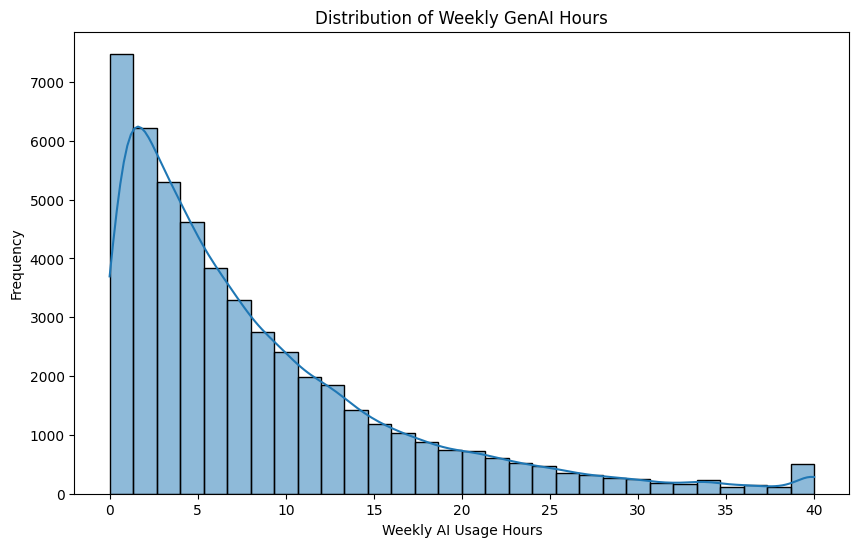

In [150]:
# Distribution of AI Usage
plt.figure(figsize=(10,6))
sns.histplot(data['Weekly_GenAI_Hours'], bins=30, kde=True)
plt.title('Distribution of Weekly GenAI Hours')
plt.xlabel('Weekly AI Usage Hours')
plt.ylabel('Frequency')
plt.show()

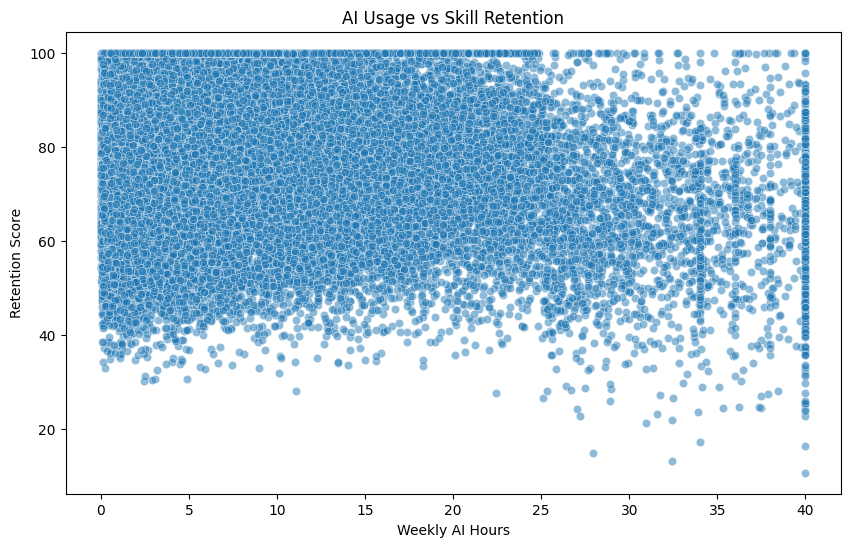

In [151]:
# AI Usage vs Retention
plt.figure(figsize=(10,6))
sns.scatterplot(data=data,x='Weekly_GenAI_Hours',y='Skill_Retention_Score',alpha=0.5)
plt.title('AI Usage vs Skill Retention')
plt.xlabel('Weekly AI Hours')
plt.ylabel('Retention Score')
plt.show()

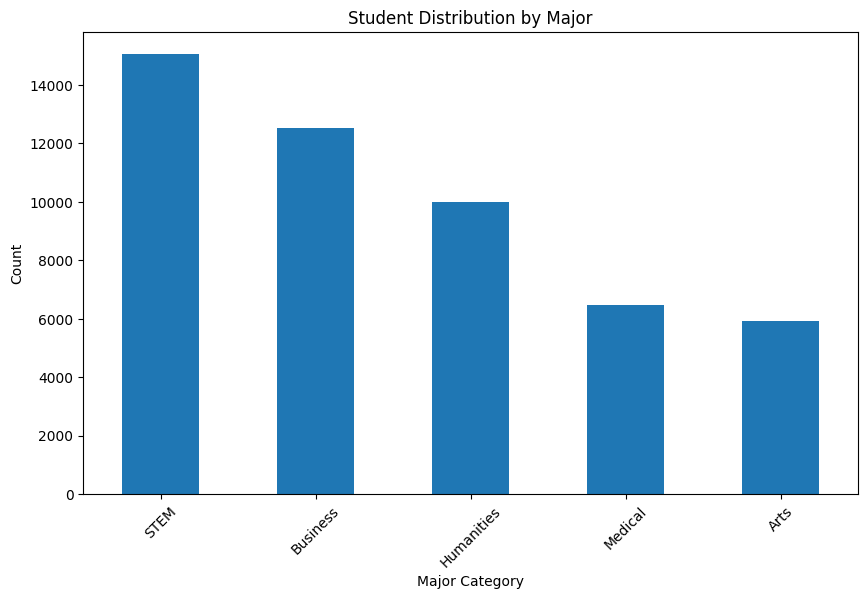

In [152]:
# Major Category Distribution
plt.figure(figsize=(10,6))
data['Major_Category'].value_counts().plot(kind='bar')
plt.title('Student Distribution by Major')
plt.xlabel('Major Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

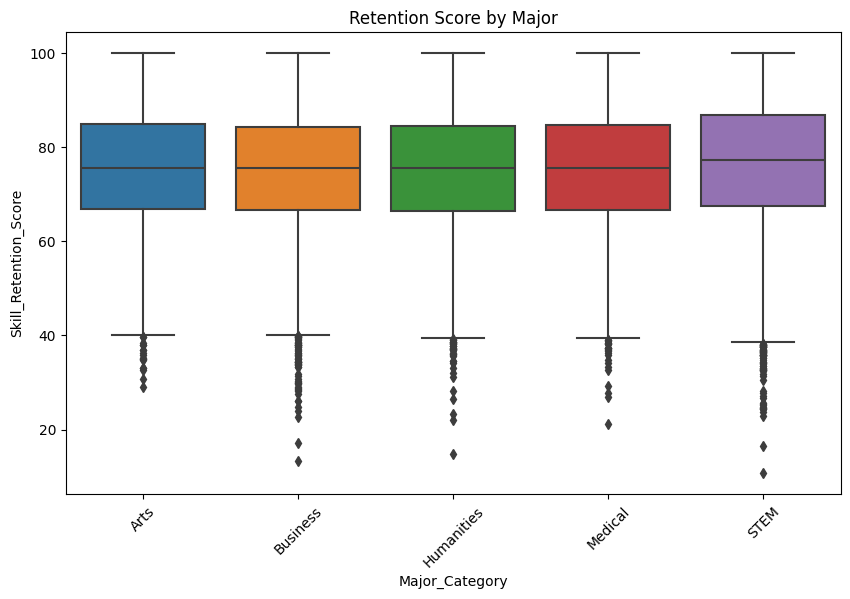

In [153]:
# Retention by Major
plt.figure(figsize=(10,6))
sns.boxplot(data = data,x = 'Major_Category',y = 'Skill_Retention_Score')
plt.title('Retention Score by Major')
plt.xticks(rotation=45)
plt.show()

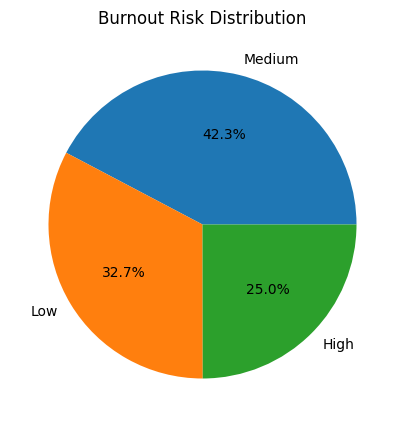

In [154]:
# Burnout Risk Levels
plt.figure(figsize=(8,5))
data['Burnout_Risk_Level'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Burnout Risk Distribution')
plt.ylabel('')
plt.show()

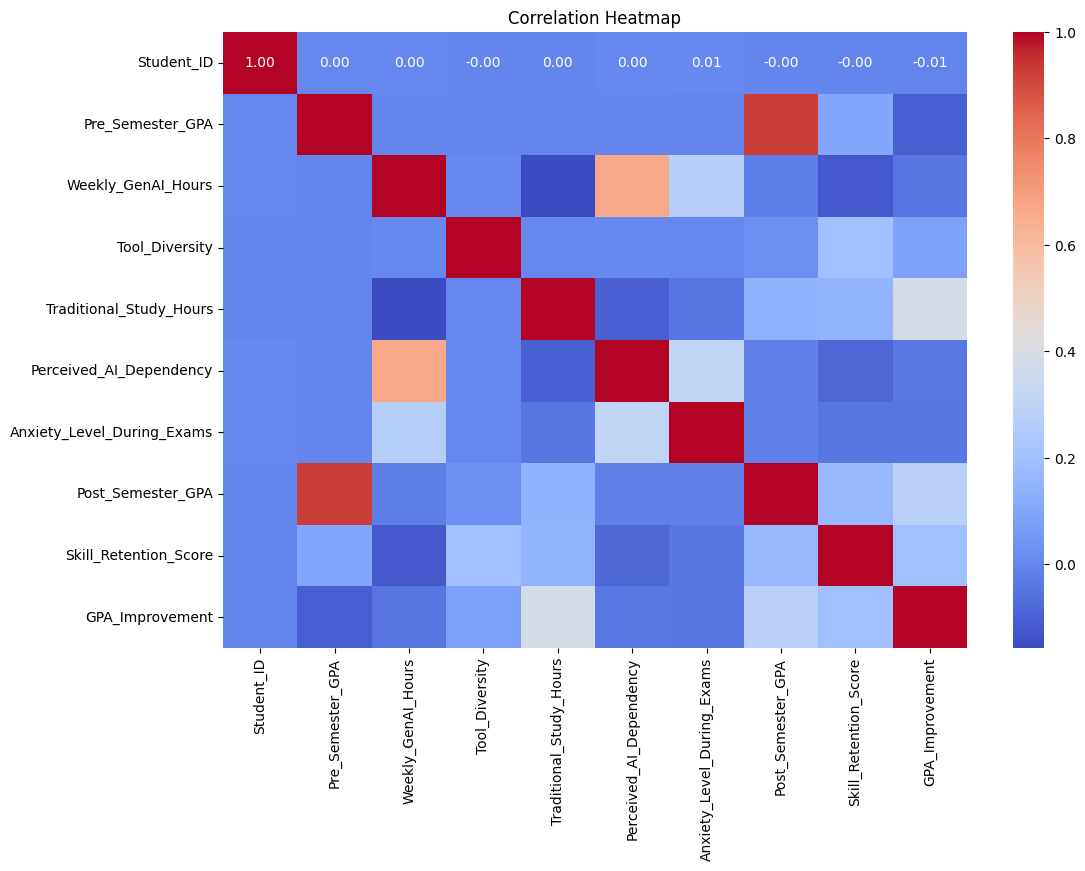

In [155]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(data[numerical_cols].corr(),annot=True,
    cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

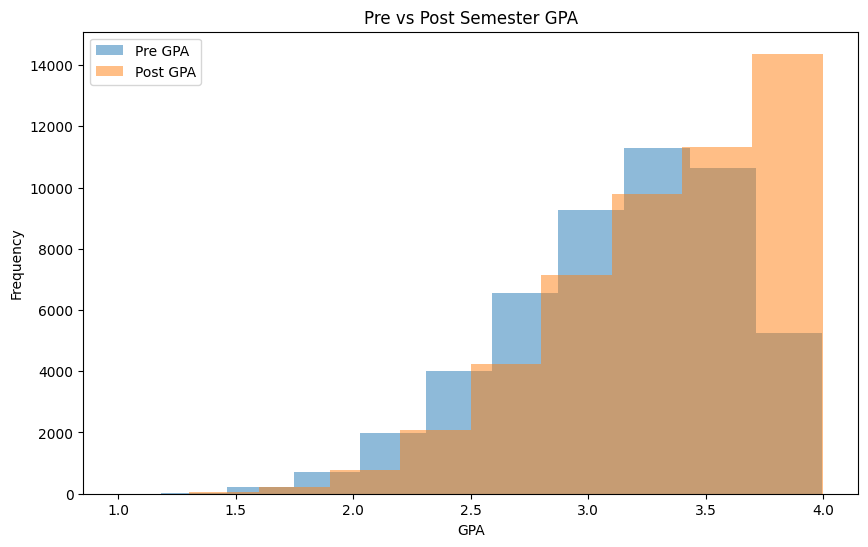

In [156]:
# GPA Before vs After
plt.figure(figsize=(10,6))
plt.hist(data['Pre_Semester_GPA'],alpha=0.5,label='Pre GPA')
plt.hist(data['Post_Semester_GPA'],alpha=0.5,label='Post GPA')
plt.title('Pre vs Post Semester GPA')
plt.xlabel('GPA')
plt.ylabel('Frequency')
plt.legend()
plt.show()

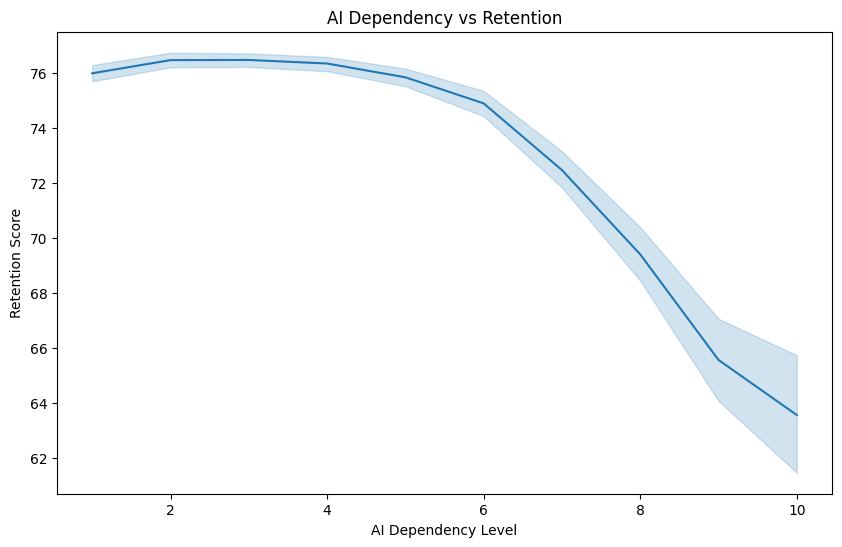

In [157]:
# AI Dependency vs Retention
plt.figure(figsize=(10,6))
sns.lineplot(data=data,x='Perceived_AI_Dependency',y='Skill_Retention_Score')
plt.title('AI Dependency vs Retention')
plt.xlabel('AI Dependency Level')
plt.ylabel('Retention Score')
plt.show()

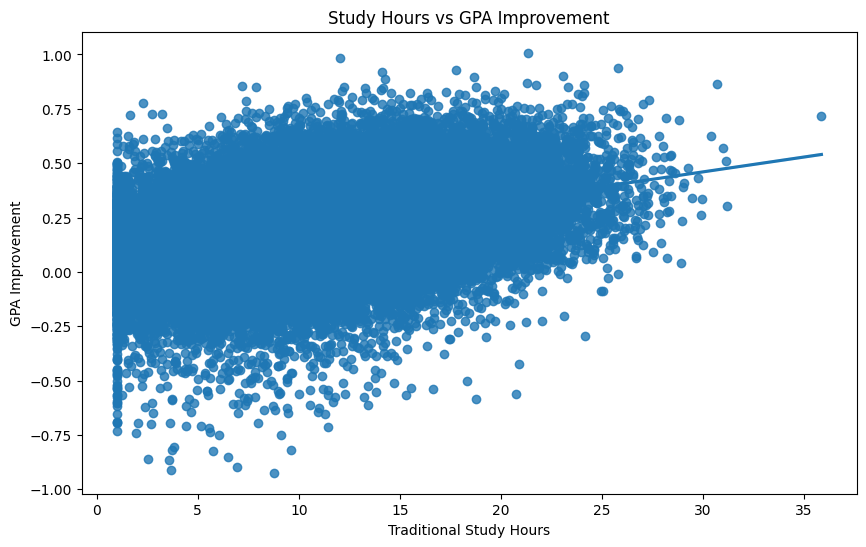

In [158]:
# Study Hours vs GPA Improvement
plt.figure(figsize=(10,6))
sns.regplot(data=data,x='Traditional_Study_Hours',y='GPA_Improvement')
plt.title('Study Hours vs GPA Improvement')
plt.xlabel('Traditional Study Hours')
plt.ylabel('GPA Improvement')
plt.show()

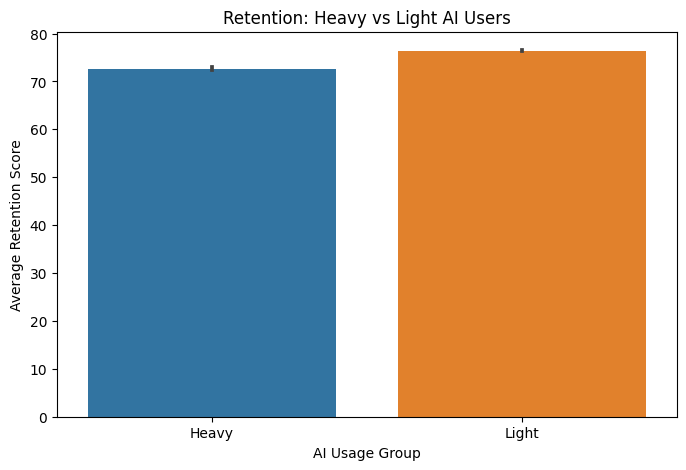

In [159]:
# Heavy vs Light AI Users
plt.figure(figsize=(8,5))
sns.barplot(data=data,x='Heavy_AI_User',y='Skill_Retention_Score')
plt.title('Retention: Heavy vs Light AI Users')
plt.xlabel('AI Usage Group')
plt.ylabel('Average Retention Score')
plt.show()

## Task 5: Predictive Model or Insight Project 
### Goal:
- Build a simple predictive model or generate meaningful insights from data.
### Examples:
- Simple prediction using regression.
- Classification of data.
- Insight-based recommendation.
### Key Skills:
- Basic machine learning concepts, model understanding.

In [160]:
# Encode categorical values
categorical_cols = data.select_dtypes( include='category').columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
# Boolean to integer
data['Paid_Subscription'] = (data['Paid_Subscription'].astype(int))

In [188]:
feat = ['Weekly_GenAI_Hours','Traditional_Study_Hours','Pre_Semester_GPA','Post_Semester_GPA','Perceived_AI_Dependency','Prompt_Engineering_Skill','Burnout_Risk_Level']
feat

['Weekly_GenAI_Hours',
 'Traditional_Study_Hours',
 'Pre_Semester_GPA',
 'Post_Semester_GPA',
 'Perceived_AI_Dependency',
 'Prompt_Engineering_Skill',
 'Burnout_Risk_Level']

In [191]:
X = data[[feat for feat in feat if feat in data.columns]]
y = data['Skill_Retention_Score']

In [192]:
# training and testing data split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [193]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, random_state=42)
}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print(f"{name} - MSE: {mse:.2f}, R2: {r2:.2f}")

Linear Regression - MSE: 160.17, R2: 0.09
Random Forest - MSE: 151.55, R2: 0.14
XGBoost - MSE: 153.69, R2: 0.13


In [194]:
import joblib
joblib.dump(models['XGBoost'], 'models/xgboost_model.pkl')

['models/xgboost_model.pkl']

In [195]:
# Feature importance 
importance_df = pd.DataFrame({'Feature': X.columns,'Importance': model.feature_importances_})
importance_df = importance_df.sort_values(by='Importance',ascending=False)
print("TOP IMPORTANT FEATURES")
print(importance_df.head(10))

TOP IMPORTANT FEATURES
                    Feature  Importance
5  Prompt_Engineering_Skill    0.613279
0        Weekly_GenAI_Hours    0.078887
3         Post_Semester_GPA    0.078564
1   Traditional_Study_Hours    0.064417
2          Pre_Semester_GPA    0.059998
6        Burnout_Risk_Level    0.052777
4   Perceived_AI_Dependency    0.052077


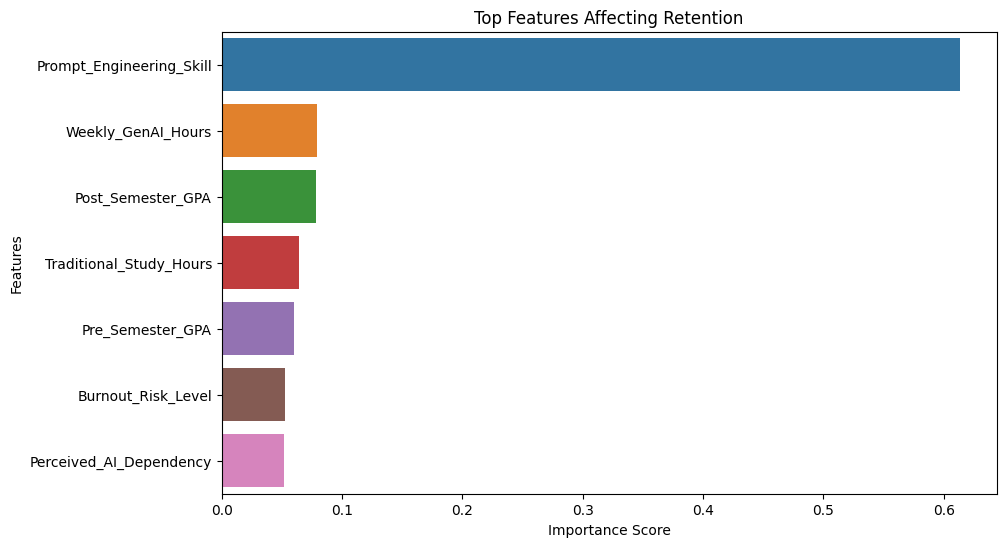

In [196]:
# Visualization of feature importance
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(10),x='Importance',y='Feature')
plt.title('Top Features Affecting Retention')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

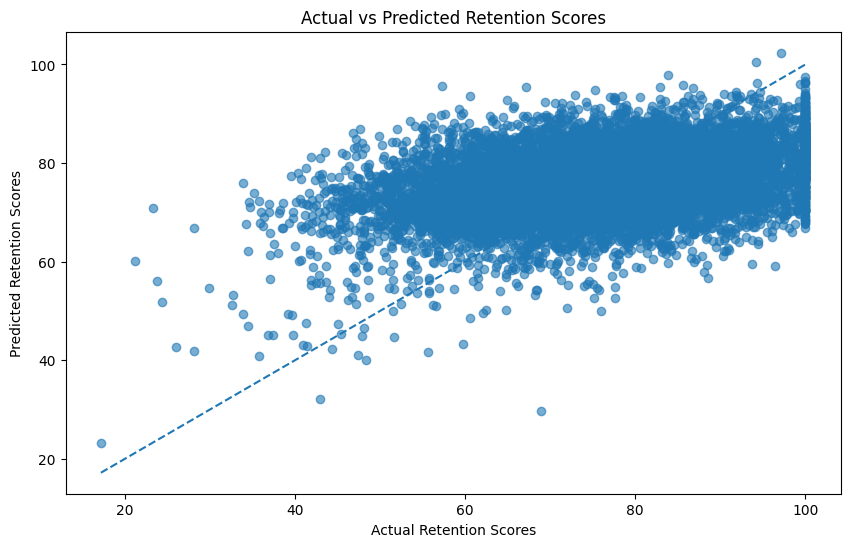

In [197]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, predictions, alpha=0.6)
plt.xlabel('Actual Retention Scores')
plt.ylabel('Predicted Retention Scores')
plt.title('Actual vs Predicted Retention Scores')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--')
plt.show()

In [199]:
# Classification Model
#features = ['Weekly_GenAI_Hours','Prompt_Engineering_Skill']
X = data[[feat for feat in feat if feat in data.columns]]
y = data['Retention_Category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [206]:
clf2 = XGBClassifier(n_estimators=200, random_state=42)
clf2.fit(X_train, y_train)
y_pred2 = clf2.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.65      0.64      5295
           1       0.59      0.57      0.58      4705

    accuracy                           0.61     10000
   macro avg       0.61      0.61      0.61     10000
weighted avg       0.61      0.61      0.61     10000

Confusion Matrix:
 [[3468 1827]
 [2040 2665]]


In [207]:
rf_model = joblib.dump(clf2, 'models/classifier2.pkl')

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.66      0.64      5295
           1       0.59      0.55      0.57      4705

    accuracy                           0.61     10000
   macro avg       0.61      0.61      0.61     10000
weighted avg       0.61      0.61      0.61     10000

Confusion Matrix:
 [[3503 1792]
 [2097 2608]]
Feature Importances:
 Weekly_GenAI_Hours          0.214115
Traditional_Study_Hours     0.209834
Pre_Semester_GPA            0.204661
Post_Semester_GPA           0.196745
Prompt_Engineering_Skill    0.075302
Perceived_AI_Dependency     0.069704
Burnout_Risk_Level          0.029638
dtype: float64


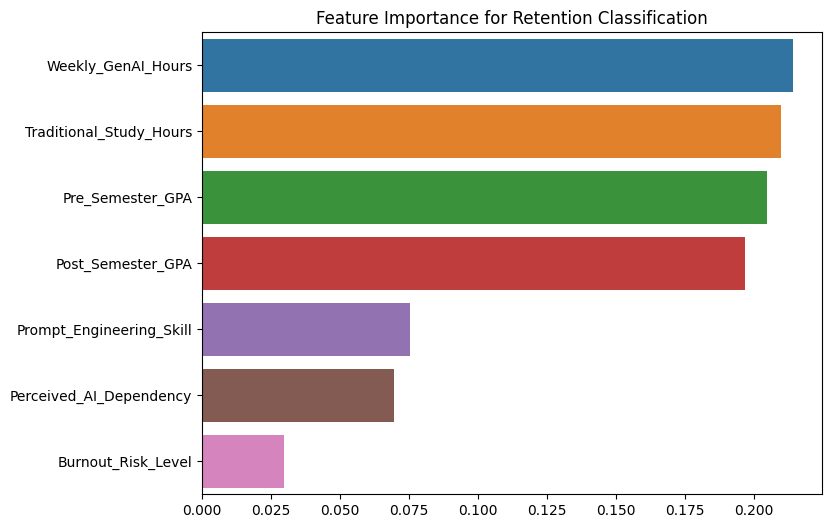

In [ ]:
# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Feature importance
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature Importances:\n", importances)

# Visualization
plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance for Retention Classification")
plt.show()